In [1]:
import os, glob, subprocess, datetime, ee, geemap

import pandas as pd
import geopandas as gpd
import numpy as np
import pickle as pkl
import scipy.stats as stats
import properscoring as ps
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.stats as stats
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

from scipy.integrate import quad
from scipy import interpolate
from scipy.stats import multivariate_normal, norm
from scipy.interpolate import make_smoothing_spline

from matplotlib.transforms import ScaledTranslation
from matplotlib import cm
from matplotlib.lines import Line2D

from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from sklearn.neighbors import KernelDensity
from sklearn.linear_model import BayesianRidge, LinearRegression

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from cartopy.mpl.geoaxes import GeoAxes

from adjustText import adjust_text

from loading_utils import (_process_solar_metadata,
                           _process_wind_metadata, 
                           _process_training_curves, 
                           _process_testing_curves, 
                           _process_traning_forecasts, 
                           _process_testing_forecasts)

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams['font.family']         = 'Avenir'

path_to_fPCA   = '/Users/Guille/Desktop/dynamic_update/software/fPCA'
path_to_fDepth = '/Users/Guille/Desktop/dynamic_update/software/fDepth'
path_to_data   = '/Users/Guille/Desktop/dynamic_update/data'
path_to_images = '/Users/Guille/Desktop/dynamic_update/images'

# Loading color palette
palette_ = pd.read_csv(path_to_data + '/palette.csv')
print(palette_)

# Loading Texas map
TX_    = gpd.read_file(path_to_data + '/maps/TX/State.shp')
ERCOT_ = gpd.read_file(path_to_data + '/maps/ERCOT/eia-mod-BW-ERCOT-shapefile.shp')

      miro      ibm
0  #013396  #648FFF
1  #B1C06E  #785EF0
2  #056534  #DC267F
3  #F80202  #FE6100
4  #FDD906  #FFB000
5  #FCF795      NaN
6  #CCEDFF      NaN
7  #FDD60B      NaN
8  #FCE9D0      NaN


In [2]:
resource = 'solar'

T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
print(F_tr_.min(), F_tr_.max())
print(E_tr_.min(), E_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ > 1.] = 1.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ > 1.] = 1.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ > 1.] = 1.
E_ts_[E_ts_ < 0.] = 0.

F_tr_solar_ = F_tr_.copy()
E_tr_solar_ = E_tr_.copy()
p_tr_solar_ = p_tr_.copy()
x_tr_solar_ = x_tr_.copy()

F_ts_solar_ = F_ts_.copy()
E_ts_solar_ = E_ts_.copy()
p_ts_solar_ = p_ts_.copy()
x_ts_solar_ = x_ts_.copy()

assets_tr_solar_ = assets_tr_.copy()
assets_ts_solar_ = assets_ts_.copy()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_      = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_      = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_      = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_      = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday 
                  for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday 
                  for t_ts in T_ts_[:, 0]]) - 1
print(t_tr_.shape, t_ts_.shape)

(211,) (211, 2) (104544,) (104544, 211) (104544, 211)
(363, 288, 211) (363, 288, 211) (363, 288)
(211,) (211, 2) (104832,) (104832, 211) (104832, 211)
(364, 288, 211) (364, 288, 211) (364, 288)
(288,) (288,)
(364, 288, 211) (364, 288, 211) (364, 288)
(211,) (211,)
0.0 1.0
-8.225737043183879e-17 1.1666666178190028
0.0 1.0
-5.384514867794431e-17 2.1269094668054778
(76593, 2) (76593, 1) (76593, 288) (76593, 288) (76593, 288)
(211, 2) (211,) (364, 288, 211) (364, 288, 211) (364, 288)
(76593,) (364,)


In [3]:
resource = 'wind'

T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
print(F_tr_.min(), F_tr_.max())
print(E_tr_.min(), E_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ > 1.] = 1.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ > 1.] = 1.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ > 1.] = 1.
E_ts_[E_ts_ < 0.] = 0.

F_tr_wind_ = F_tr_.copy()
E_tr_wind_ = E_tr_.copy()
p_tr_wind_ = p_tr_.copy()
x_tr_wind_ = x_tr_.copy()

F_ts_wind_ = F_ts_.copy()
E_ts_wind_ = E_ts_.copy()
p_ts_wind_ = p_ts_.copy()
x_ts_wind_ = x_ts_.copy()

assets_tr_wind_ = assets_tr_.copy()
assets_ts_wind_ = assets_ts_.copy()

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_      = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_      = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_      = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_      = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday 
                  for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday 
                  for t_ts in T_ts_[:, 0]]) - 1
print(t_tr_.shape, t_ts_.shape)

(187,) (187, 2) (104544,) (104544, 187) (104544, 187)
(363, 288, 187) (363, 288, 187) (363, 288)
(187,) (187, 2) (104832,) (104832, 187) (104832, 187)
(364, 288, 187) (364, 288, 187) (364, 288)
(288,) (288,)
(364, 288, 187) (364, 288, 187) (364, 288)
(187,) (187,)
0.0 1.0
-0.00014310971827851548 0.9999999888984703
0.0 1.0
-5.626724167500701e-18 1.113073847912657
(67881, 2) (67881, 1) (67881, 288) (67881, 288) (67881, 288)
(187, 2) (187,) (364, 288, 187) (364, 288, 187) (364, 288)
(67881,) (364,)


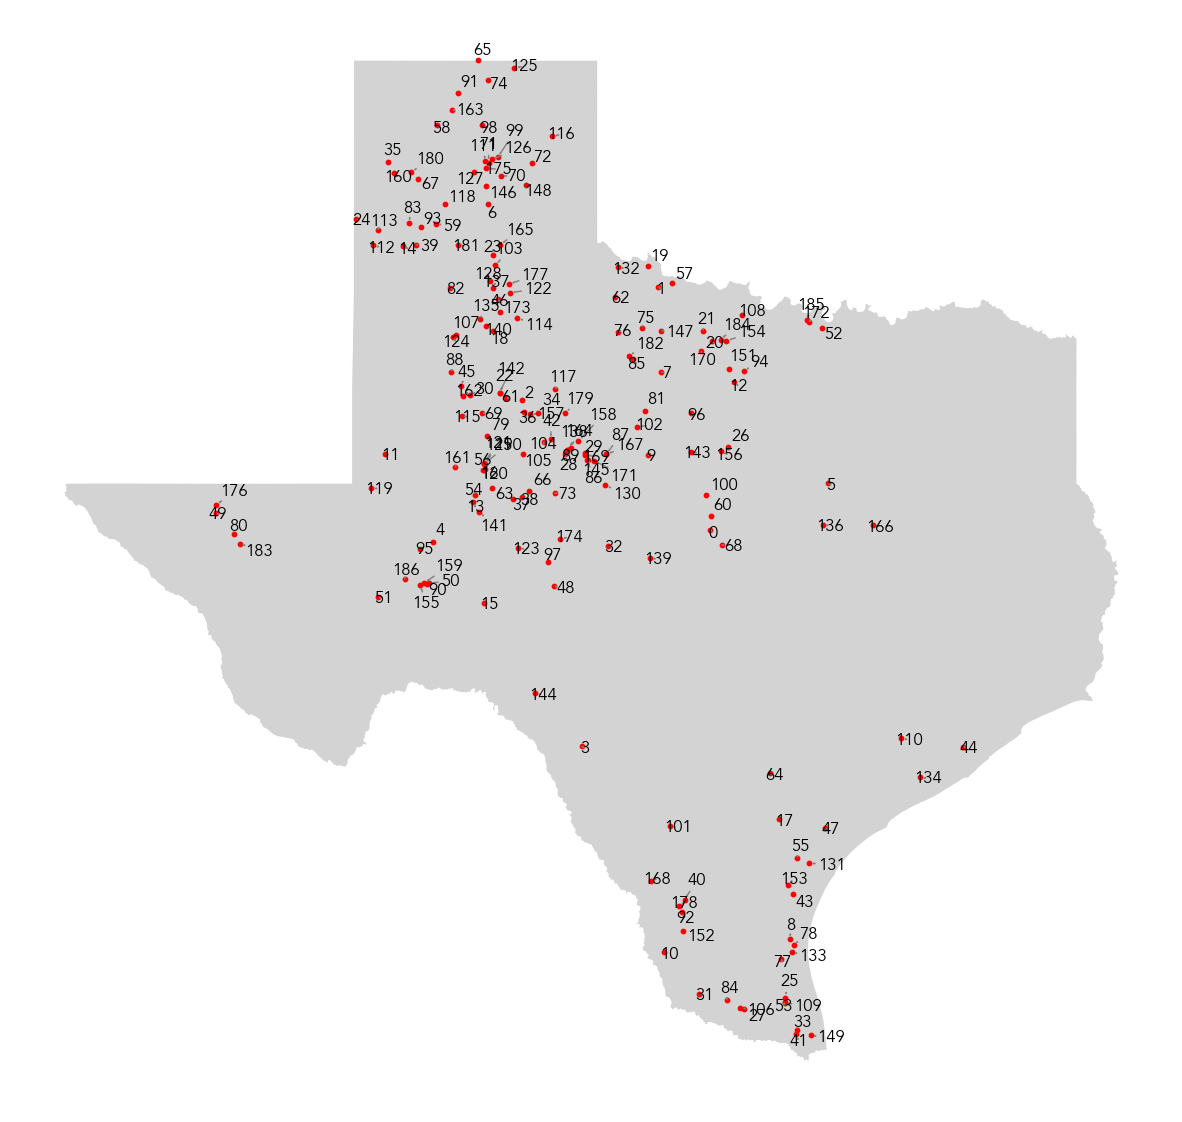

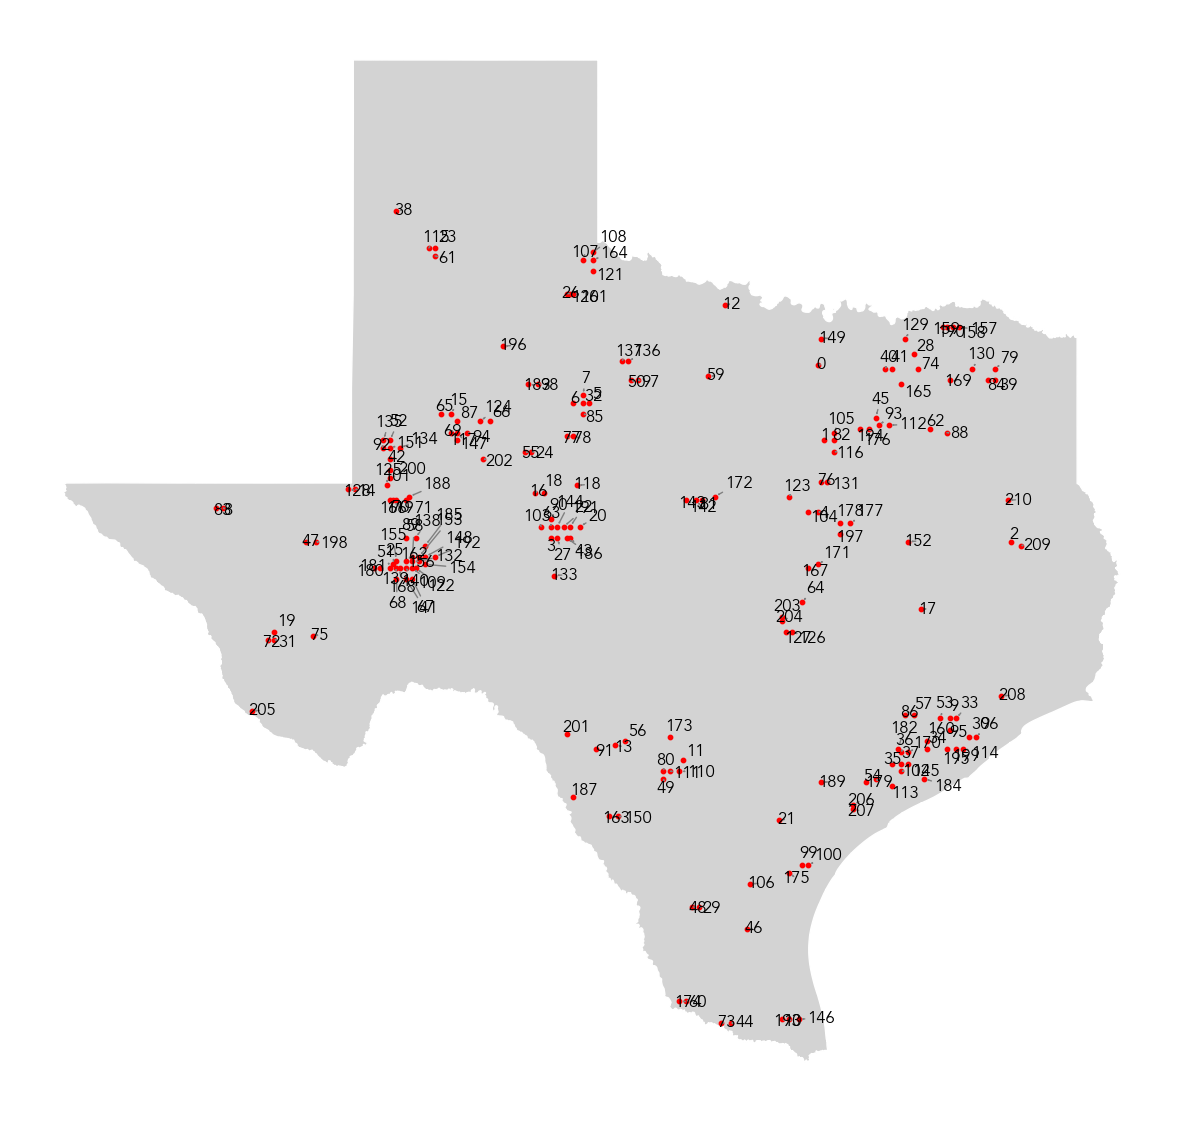

In [4]:
def _plot_asset_ids(_ax, x_ts_, assets_ts_):

    TX_.plot(ax        = _ax, 
             facecolor = 'lightgray', 
             edgecolor = 'white')
    
    _ax.scatter(x_ts_[:, 0], x_ts_[:, 1], 
                s = 10., 
                c = 'r', 
                marker = 'o')
    
    # Create annotation texts
    labels_ = [f'{assets_ts_[i]}' for i in range(assets_ts_.shape[0])]
    labels_ = [f'{i}' for i in range(assets_ts_.shape[0])]
    texts_  = [_ax.text(x_ts_[i, 0], x_ts_[i, 1], label, fontsize=12) for i, label in enumerate(labels_)]
    
    # Adjust text to avoid overlap
    adjust_text(texts_, arrowprops = dict(arrowstyle='->', color='gray'))
    
    _ax.set_axis_off()

fig, _ax = plt.subplots(figsize = (15, 15))  # Adjust figure size as needed

_plot_asset_ids(_ax, x_ts_wind_, assets_ts_wind_)

plt.savefig(path_to_images + f'/wind_index.pdf', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

fig, _ax = plt.subplots(figsize = (15, 15))  # Adjust figure size as needed

_plot_asset_ids(_ax, x_ts_solar_, assets_ts_solar_)

plt.savefig(path_to_images + f'/solar_index.pdf', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()

NameError: name '_ax_parent' is not defined

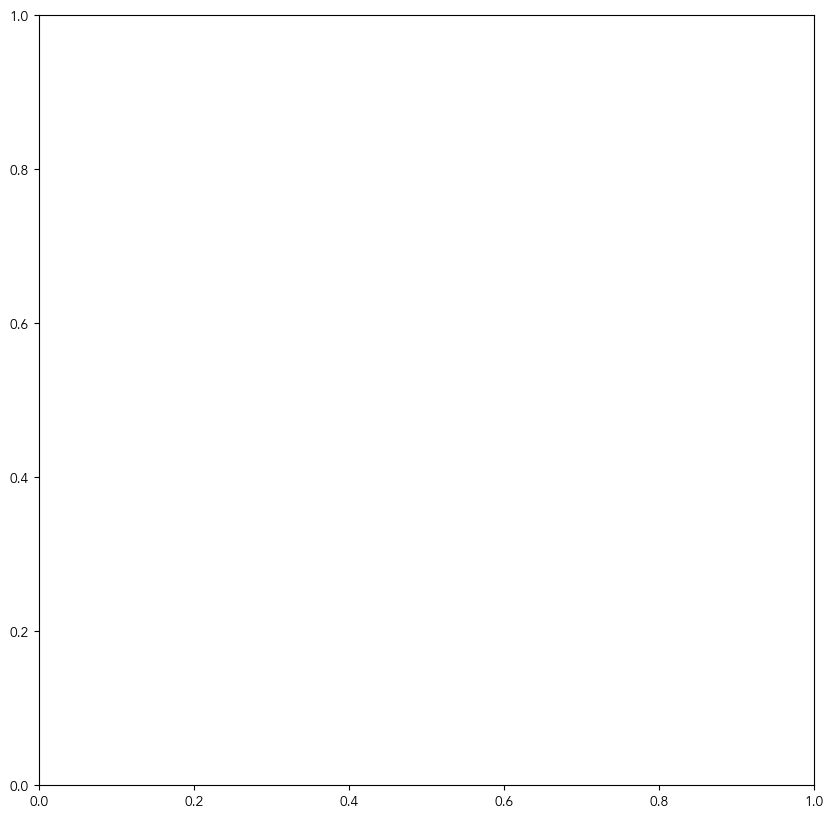

In [5]:
def _globe_inset(_ax, shape_, x0, y0, width=0.25, height=0.25):
    """
    Add an orthographic globe inset centered on Texas.

    Parameters
    ----------
    ax_parent : matplotlib Axes / GeoAxes
        Parent axes where the inset will be placed.
    TX_ : GeoDataFrame
        Texas geometry.
    x0, y0 : float
        Lower-left corner of the inset in parent axes coordinates (0–1).
    width, height : float
        Size of the inset, also in parent axes coordinates (0–1).
    """

    # --- Data prep ---
    world_ = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    world_ = world_.to_crs(epsg=4326)
    shape_ = shape_.to_crs(epsg=4326)

    tx_centroid = shape_.geometry.unary_union.centroid

    ortho = ccrs.Orthographic(central_longitude=tx_centroid.x,
                              central_latitude=tx_centroid.y)

    # Use inset_axes *function*, not ax_parent.inset_axes
    # bbox_to_anchor=(x0, y0, width, height) is in ax_parent.transAxes
    _ax_inset = inset_axes(_ax,
                           width="100%",   # 100% of the bbox width
                           height="100%",  # 100% of the bbox height
                           bbox_to_anchor=(x0, y0, width, height),
                           bbox_transform=_ax_parent.transAxes,
                           axes_class=GeoAxes,
                           axes_kwargs=dict(map_projection=ortho),
                           borderpad=0.0)

    # --- Drawing ---
    _ax_inset.add_geometries(world_.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="k",
                             linewidth=0.25)

    _ax_inset.add_geometries(TX_.geometry,
                             crs=ccrs.PlateCarree(),
                             facecolor="none",
                             edgecolor="r",
                             zorder=10,
                             linewidth=.75)

    gl = _ax_inset.gridlines(crs=ccrs.PlateCarree(),
                             draw_labels=False,      # no labels – small inset
                             linewidth=0.4,
                             color="white",
                             alpha=.825,
                             xlocs=range(-180, 181, 15),
                             ylocs=range(-90, 91, 15))
    
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    _ax_inset.coastlines(linewidth=0.5)
    _ax_inset.add_feature(cfeature.OCEAN, zorder=0)
    _ax_inset.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    _ax_inset.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=2)
    _ax_inset.set_global()

def _hillshade(_ax, shapefile_):

    # Initialize Earth Engine
    ee.Initialize()
    
    # Get the bounding box from 
    bounds = TX_.total_bounds  # [minx, miny, maxx, maxy]
    roi = geemap.geopandas_to_ee(TX_)  # Convert GeoDataFrame to EE FeatureCollection
    
    _DEM = ee.Image('USGS/SRTMGL1_003').select('elevation')
    #hillshade = ee.Terrain.hillshade(_DEM, 180, 22.5)
    hillshade = ee.Terrain.hillshade(_DEM, 315, 21)
    #hillshade = ee.Terrain.hillshade(_DEM, 315, 20).unitScale(0, 255).pow(1.4).multiply(255) 

    # Download hillshade as a NumPy array
    hillshade_np = geemap.ee_to_numpy(hillshade.clip(roi), 
                                      region=roi, 
                                      scale=1000).astype(float)

    hs = hillshade_np.squeeze()
    hs[hs == 0] = np.nan

    # Create a colormap and set NaNs (bad values) to transparent
    _cmap = cm.get_cmap("Greys_r").copy()
    #_cmap = cm.get_cmap("gray").copy()
    _cmap.set_bad(color=(0, 0, 0, 0))  # RGBA: transparent

    _ax.imshow(hs, 
               cmap=_cmap, 
               extent=[bounds[0], bounds[2], bounds[1], bounds[3]], 
               origin='upper', 
               vmin=1)
    
    return _ax

fig, _ax = plt.subplots(figsize = (10, 10))  # Adjust figure size as needed

# Add inset globe showing Texas
_globe_inset(_ax, TX_, 
             x0=0.05, 
             y0=0.7, 
             width=0.2, 
             height=0.2)

_ax = _hillshade(_ax, TX_)

TX_.plot(ax        = _ax, 
         facecolor = 'none', 
         edgecolor = 'w')

scale = 50

_ax.scatter(x_ts_wind_[:, 0], x_ts_wind_[:, 1], 
            s     = np.pi * (p_ts_wind_/scale)**2,
            c     = '#8dc0cd', 
            alpha = 0.625)

_ax.scatter(x_ts_wind_[:, 0], x_ts_wind_[:, 1], 
            s         = np.pi * (p_ts_wind_/scale)**2,
            edgecolor = 'k', 
            lw        = .125, 
            facecolor = 'None')

_ax.scatter(x_ts_solar_[:, 0], x_ts_solar_[:, 1], 
            s     = np.pi * (p_ts_solar_/scale)**2,
            c     = '#ef9226', 
            alpha = 0.625)

_ax.scatter(x_ts_solar_[:, 0], x_ts_solar_[:, 1], 
            s         = np.pi * (p_ts_solar_/scale)**2,
            edgecolor = 'k', 
            lw        = .125, 
            facecolor = 'None')

loc_    = [-97.5, 35.5]
sizes_  = np.array([1000, 666, 333])/scale
labels_ = ['1,000MW', '500MW', '250MW', ]

texts_ = []
for r, label, i in zip(sizes_, labels_, range(len(labels_))):
    _ax.scatter(loc_[0], loc_[1] + (r - sizes_[0])/50, 
                s         = np.pi * r**2,
                edgecolor = 'k', 
                lw        = .75, 
                facecolor = 'None')
    
    _ax.text(loc_[0] + (r - sizes_[0])/50 + .625, 
             loc_[1] + (r - sizes_[0])/50 + .1*(len(labels_) - i) - .15, 
             label, 
             fontsize=12, 
             ha='left', 
             va='center')

# Adjust text to avoid overlap
adjust_text(texts_, arrowprops = dict(arrowstyle='->', color='gray'))

# Add compass (North arrow)
x, y, arrow_length = 0.14, 0.225, 0.06  # relative axes coords

_ax.annotate('N', 
             xy         = (x, y), 
             xytext     = (x, y - arrow_length),
             ha         = 'center', 
             va         = 'center',
             fontsize   = 12,
             xycoords   = _ax.transAxes, 
             arrowprops = dict(facecolor='k', 
                               arrowstyle='wedge,tail_width=1,shrink_factor=.5'))

scalebar = ScaleBar(dx              = 100,  # scaling factor
                    units           = 'km', 
                    dimension       = 'si-length',  # could also be 'imperial-length'
                    location        = 'lower left',
                    length_fraction = .10,  # fraction of the axis for bar length
                    color           = 'black',
                    box_color       = 'None',
                    box_alpha       = 1.,
                    border_pad      = 5,
                    font_properties = {'size': 12})

_ax.add_artist(scalebar)

_ax.set_axis_off()

plt.savefig(path_to_images + f"/loc_map.pdf", 
            bbox_inches="tight", 
            dpi=600)

plt.savefig(path_to_images + f"/loc_map.png", 
            bbox_inches="tight", 
            dpi=600)

plt.show()

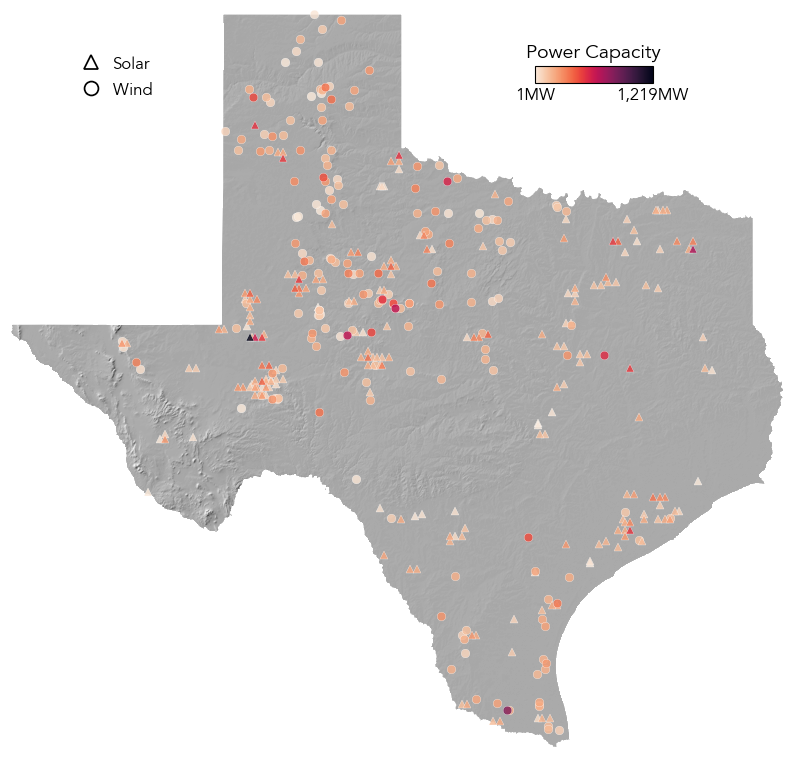

In [6]:
def _spatial_capacity(_fig, _ax, TX_, x_, p_, z_,
                      cmap = "rocket_r",
                      legend = True):    
    
    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = plt.Normalize(p_.min(), p_.max())
    
    _ax = _hillshade(_ax, TX_)
    
    TX_.plot(ax = _ax, 
             facecolor = 'None', 
             edgecolor = 'white')
    
    for i in np.arange(x_.shape[0], dtype=int)[np.argsort(p_)]:
        if z_[i] == 0:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(p_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker='^',
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
        if z_[i] == 1:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(p_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker='o',
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)

    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], 
                                            transform = _ax.transData),
                         orientation="horizontal")
    
    cbar.set_ticks([0, 1], 
                   labels=[f"{int(np.around(p_.min(), 0)):,.0f}MW", 
                           f"{int(np.around(p_.max(), 0)):,.0f}MW"], 
                   fontsize=12)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Power Capacity", 
                      rotation = 0, 
                      fontsize = 14)

    _ax.set_axis_off()

x_ts_ = np.concatenate([x_ts_solar_, x_ts_wind_], axis = 0)
p_ts_ = np.concatenate([p_ts_solar_, p_ts_wind_], axis = 0)
z_ts_ = np.concatenate([np.zeros(p_ts_solar_.shape), 
                        np.ones(p_ts_wind_.shape)], axis = 0)


_fig, _ax = plt.subplots(figsize=(10, 10)) 

_ax = _hillshade(_ax, TX_)

_spatial_capacity(_fig, _ax, TX_, x_ts_, p_ts_, z_ts_,
                  cmap = "rocket_r")    

# # Add compass (North arrow)
# x, y, arrow_length = 0.14, 0.225, 0.06  # relative axes coords

# _ax.annotate('N', 
#              xy = (x, y), 
#              xytext = (x, y - arrow_length),
#              ha = 'center', 
#              va = 'center',
#              fontsize = 12,
#              xycoords = _ax.transAxes, 
#              arrowprops = dict(facecolor='k', 
#                                arrowstyle='wedge,tail_width=1,shrink_factor=.5'))

# scalebar = ScaleBar(dx = 100,  # scaling factor
#                     units = 'km', 
#                     dimension = 'si-length',  # could also be 'imperial-length'
#                     location = 'lower left',
#                     length_fraction = .10,  # fraction of the axis for bar length
#                     color = 'black',
#                     box_color = 'None',
#                     box_alpha = 1.,
#                     border_pad = 5,
#                     font_properties = {'size': 12})

# _ax.add_artist(scalebar)

# Custom legend markers
legend_elements_ = [Line2D([0], [0], marker='^', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Solar'),
                    Line2D([0], [0], marker='o', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Wind')]

_ax.legend(loc=(0.085, 0.875),
           frameon=False,
           handles=legend_elements_, 
           fontsize=12)

plt.savefig(path_to_images + r"/cap_map.pdf", 
            bbox_inches="tight")

plt.show()

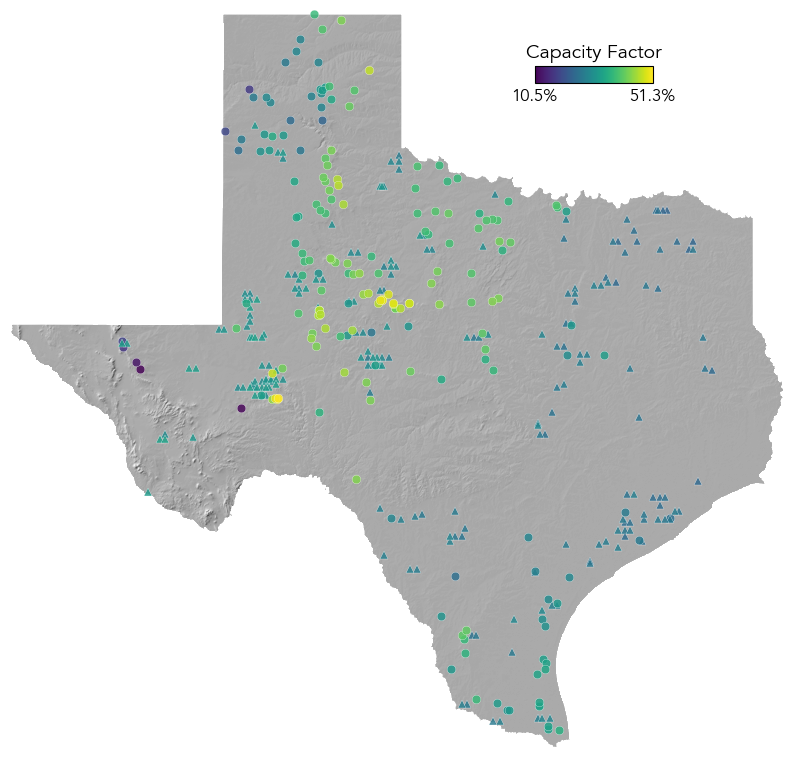

In [7]:
def _spatial_capacity_factors(_fig, _ax, TX_, x_, f_, z_,
                              cmap = "viridis"):
    
    
    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = plt.Normalize(f_.min(), f_.max())
    
    _ax = _hillshade(_ax, TX_)

    TX_.plot(ax        = _ax, 
             facecolor = 'None', 
             edgecolor = 'white')
    
    for i in np.arange(x_.shape[0], dtype=int)[np.argsort(f_)]:
        if z_[i] == 0:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(f_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker='^',
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
        if z_[i] == 1:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(f_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker='o',
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
            
    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], 
                                            transform = _ax.transData),
                         orientation="horizontal")
    
    cbar.set_ticks([0, 1], 
                   labels=[f"{np.around(100*f_.min(), 1)}%", 
                           f"{np.around(100*f_.max(), 1)}%"], 
                   fontsize=12)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Capacity Factor", 
                      rotation = 0, 
                      fontsize = 14)
    
    _ax.set_axis_off()

_fig, _ax = plt.subplots(figsize = (10, 10))  # Adjust figure size as neede

f_ts_solar_ = np.mean(np.mean(F_ts_solar_, axis = 0), axis = 0)
f_ts_wind_ = np.mean(np.mean(F_ts_wind_, axis = 0), axis = 0)

x_ts_ = np.concatenate([x_ts_solar_, x_ts_wind_], axis = 0)
f_ts_ = np.concatenate([f_ts_solar_, f_ts_wind_], axis = 0)
z_ts_ = np.concatenate([np.zeros(f_ts_solar_.shape), 
                        np.ones(f_ts_wind_.shape)], axis = 0)

_spatial_capacity_factors(_fig, _ax, TX_, x_ts_, f_ts_, z_ts_,
                          cmap = "viridis")

# # Add compass (North arrow)
# x, y, arrow_length = 0.14, 0.225, 0.06  # relative axes coords

# _ax.annotate('N', 
#              xy = (x, y), 
#              xytext = (x, y - arrow_length),
#              ha = 'center', 
#              va = 'center',
#              fontsize = 12,
#              xycoords = _ax.transAxes, 
#              arrowprops = dict(facecolor='k', 
#                                arrowstyle='wedge,tail_width=1,shrink_factor=.5'))

# scalebar = ScaleBar(dx = 100,  # scaling factor
#                     units = 'km', 
#                     dimension = 'si-length',  # could also be 'imperial-length'
#                     location = 'lower left',
#                     length_fraction = .10,  # fraction of the axis for bar length
#                     color = 'black',
#                     box_color = 'None',
#                     box_alpha = 1.,
#                     border_pad = 5,
#                     font_properties = {'size': 12})

# _ax.add_artist(scalebar)

# # Custom legend markers
# legend_elements_ = [Line2D([0], [0], marker='^', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Solar'),
#                     Line2D([0], [0], marker='o', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Wind')]

# _ax.legend(loc=(0.085, 0.875),
#            frameon=False,
#            handles=legend_elements_, 
#            fontsize=12)

plt.savefig(path_to_images + r"/cf_map.pdf", 
            bbox_inches="tight")

plt.show()

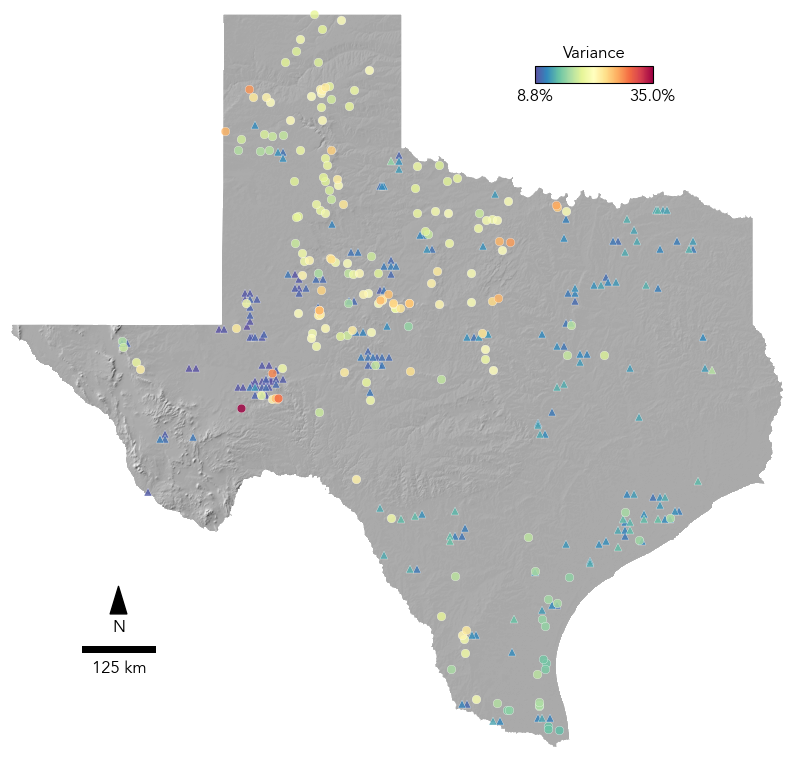

In [8]:
def _spatial_errors(_fig, _ax, TX_, e_, x_, p_, z_,
                    cmap = "cividis"):
    
    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = plt.Normalize(e_.min(), e_.max())

    _ax = _hillshade(_ax, TX_)

    TX_.plot(ax        = _ax, 
             facecolor = 'None', 
             edgecolor = 'white')
    
    for i in np.arange(x_.shape[0], dtype=int)[np.argsort(e_)]:
        if z_[i] == 0:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(e_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker="^",
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
        if z_[i] == 1:
            _ax.plot(x_[i, 0], x_[i, 1],
                     c=_cmap(_norm(e_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker="o",
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
            
    cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
                         orientation="horizontal",
                         cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], 
                                            transform = _ax.transData))
    
    cbar.set_ticks([0, 1], 
                   labels=[f"{np.around(100*e_.min(), 1)}%", 
                           f"{np.around(100*e_.max(), 1)}%"], 
                   fontsize=12)
    
    cbar.ax.tick_params(length=0)
    
    cbar.ax.set_title("Variance", 
                      rotation = 0, 
                      fontsize = 12)

    _ax.set_axis_off()

_fig, _ax = plt.subplots(figsize = (10, 10))  # Adjust figure size as neede

e_ts_solar_ = np.mean(np.sqrt(np.mean((F_ts_solar_ - E_ts_solar_)**2, axis = 0)), axis = 0)
e_ts_wind_  = np.mean(np.sqrt(np.mean((F_ts_wind_ - E_ts_wind_)**2, axis = 0)), axis = 0)

x_ts_ = np.concatenate([x_ts_solar_, x_ts_wind_], axis = 0)
e_ts_ = np.concatenate([e_ts_solar_, e_ts_wind_], axis = 0)
z_ts_ = np.concatenate([np.zeros(e_ts_solar_.shape), 
                        np.ones(e_ts_wind_.shape)], axis = 0)

_spatial_errors(_fig, _ax, TX_, e_ts_, x_ts_, p_ts_, z_ts_,
                cmap = "Spectral_r")

# Add compass (North arrow)
x, y, arrow_length = 0.14, 0.225, 0.06  # relative axes coords

_ax.annotate('N', 
             xy         = (x, y), 
             xytext     = (x, y - arrow_length),
             ha         = 'center', 
             va         = 'center',
             fontsize   = 12,
             xycoords   = _ax.transAxes, 
             arrowprops = dict(facecolor='k', 
                               arrowstyle='wedge,tail_width=1,shrink_factor=.5'))

scalebar = ScaleBar(dx              = 100,  # scaling factor
                    units           = 'km', 
                    dimension       = 'si-length',  # could also be 'imperial-length'
                    location        = 'lower left',
                    length_fraction = .10,  # fraction of the axis for bar length
                    color           = 'black',
                    box_color       = 'None',
                    box_alpha       = 1.,
                    border_pad      = 5,
                    font_properties = {'size': 12})

_ax.add_artist(scalebar)

# # Custom legend markers
# legend_elements_ = [Line2D([0], [0], marker='^', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Solar'),
#                     Line2D([0], [0], marker='o', ms=10, mew=1.25, mec='k', mfc='none', ls='None', label='Wind')]

# _ax.legend(loc=(0.085, 0.875),
#            frameon=False,
#            handles=legend_elements_, 
#            fontsize=12)

plt.savefig(path_to_images + r"/variance_map.pdf", 
            bbox_inches="tight")

plt.show()

In [ ]:
# def _spatial_bias(_fig, _ax, TX_, e_, x_, p_, z_,
#                   cmap = "cividis"):
    
#     _cmap = sns.color_palette(cmap, as_cmap = True)
#     _norm = plt.Normalize(e_.min(), e_.max())

#     _ax = _hillshade(_ax, TX_)

#     TX_.plot(ax        = _ax, 
#              facecolor = 'None', 
#              edgecolor = 'white')
    
#     for i in np.arange(x_.shape[0], dtype=int)[np.argsort(e_)]:
#         if z_[i] == 0:
#             _ax.plot(x_[i, 0], x_[i, 1],
#                      c=_cmap(_norm(e_[i])),
#                      alpha=0.825,
#                      ms=6.25,
#                      ls="none",
#                      marker="^",
#                      mec="w",
#                      mew=.25,
#                      zorder=4, 
#                      clip_on=False)
#         if z_[i] == 1:
#             _ax.plot(x_[i, 0], x_[i, 1],
#                      c=_cmap(_norm(e_[i])),
#                      alpha=0.825,
#                      ms=6.25,
#                      ls="none",
#                      marker="o",
#                      mec="w",
#                      mew=.25,
#                      zorder=4, 
#                      clip_on=False)
            
#     cbar = _fig.colorbar(cm.ScalarMappable(cmap = _cmap),
#                          orientation="horizontal",
#                          cax=_ax.inset_axes([-97.75, 35.5, 2.0, 0.25], 
#                                             transform = _ax.transData))
    
#     cbar.set_ticks([0, 1], 
#                    labels=[f"{np.around(100*e_.min(), 1)}%", 
#                            f"{np.around(100*e_.max(), 1)}%"], 
#                    fontsize=12)
    
#     cbar.ax.tick_params(length=0)
    
#     cbar.ax.set_title("MBE", 
#                       rotation = 0, 
#                       fontsize = 12)

#     _ax.set_axis_off()

# _fig, _ax = plt.subplots(figsize = (10, 10))  # Adjust figure size as neede

# b_ts_solar_ = np.mean(np.mean(F_ts_solar_ - E_ts_solar_, axis = 0), axis = 0)
# b_ts_wind_  = np.mean(np.mean(F_ts_wind_ - E_ts_wind_, axis = 0), axis = 0)

# x_ts_ = np.concatenate([x_ts_solar_, x_ts_wind_], axis = 0)
# b_ts_ = np.concatenate([e_ts_solar_, e_ts_wind_], axis = 0)
# z_ts_ = np.concatenate([np.zeros(e_ts_solar_.shape), 
#                         np.ones(e_ts_wind_.shape)], axis = 0)
# # x_ts_ = x_ts_wind_
# # b_ts_ = b_ts_wind_
# # z_ts_ = np.ones(b_ts_wind_.shape)

# _spatial_bias(_fig, _ax, TX_, b_ts_, x_ts_, p_ts_, z_ts_,
#               cmap = "Spectral_r")

# # Add compass (North arrow)
# x, y, arrow_length = 0.14, 0.225, 0.06  # relative axes coords

# _ax.annotate('N', 
#              xy         = (x, y), 
#              xytext     = (x, y - arrow_length),
#              ha         = 'center', 
#              va         = 'center',
#              fontsize   = 12,
#              xycoords   = _ax.transAxes, 
#              arrowprops = dict(facecolor='k', 
#                                arrowstyle='wedge,tail_width=1,shrink_factor=.5'))

# scalebar = ScaleBar(dx              = 100,  # scaling factor
#                     units           = 'km', 
#                     dimension       = 'si-length',  # could also be 'imperial-length'
#                     location        = 'lower left',
#                     length_fraction = .10,  # fraction of the axis for bar length
#                     color           = 'black',
#                     box_color       = 'None',
#                     box_alpha       = 1.,
#                     border_pad      = 5,
#                     font_properties = {'size': 12})

# _ax.add_artist(scalebar)

# plt.savefig(path_to_images + f"/bias_map.pdf", 
#             bbox_inches="tight")

# plt.show()

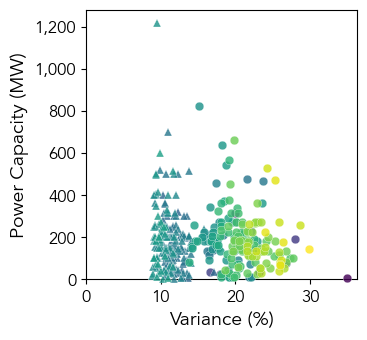

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


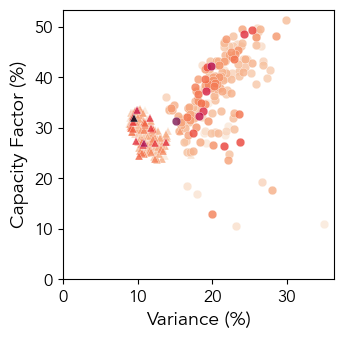

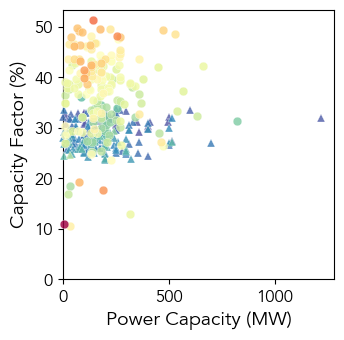

In [9]:
def _scatter_plot(_ax, x_, y_, z_, w_,
                  cmap   = "rocket_r",
                  xlabel = None,
                  ylabel = None, 
                  legend = False):
        
    _cmap = sns.color_palette(cmap, as_cmap=True)
    _norm = plt.Normalize(z_.min(), z_.max())
    
    for i in np.arange(z_.shape[0], dtype=int)[np.argsort(z_)]:
        if w_[i] == 0:
            _ax.plot(x_[i], y_[i],
                     c=_cmap(_norm(z_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker="^",
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)
        if w_[i] == 1:
            _ax.plot(x_[i], y_[i],
                     c=_cmap(_norm(z_[i])),
                     alpha=0.825,
                     ms=6.25,
                     ls="none",
                     marker="o",
                     mec="w",
                     mew=.25,
                     zorder=4, 
                     clip_on=False)

    _ax.set_xlim(0,)
    _ax.set_ylim(0,)
    
    # x_min, x_max = _ax.get_xlim()

    # xline = np.linspace(x_min, x_max, 1000)

    # m, b = np.polyfit(x_[w_ == 1], y_[w_ == 1], 1)
    # _ax.plot(xline, m*xline + b, lw=.75, ls = '-', c = 'k', zorder = 10, label = 'Wind (fit)')

    # m, b = np.polyfit(x_[w_ == 0], y_[w_ == 0], 1)
    # _ax.plot(xline, m*xline + b, lw=.75, ls = '--', c = 'k', zorder = 10, label = 'Solar (fit)')

    _ax.tick_params(axis="both", 
                    labelsize=12)

    if xlabel is None:
        _ax.set_xticks([])
    else:
        _ax.set_xlabel(xlabel, size=14)
    
    if ylabel is None:
        _ax.set_yticks([])
    else:
        _ax.set_ylabel(ylabel, size=14)

    _ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    if legend:   
        _ax.legend(frameon = False,
                   fontsize=12)

_fig, _ax = plt.subplots(figsize =(3.5, 3.5))  # Adjust figure size as neede

idx_ = z_ts_ != 2.

_scatter_plot(_ax, 100.*e_ts_[idx_], p_ts_[idx_], f_ts_[idx_], z_ts_[idx_],
              xlabel = 'Variance (%)', 
              ylabel = 'Power Capacity (MW)', 
              cmap = 'viridis',
              legend = False)

plt.savefig(path_to_images + r"/fce_vs_cap.pdf", 
            bbox_inches="tight")

plt.show()

_fig, _ax = plt.subplots(figsize=(3.5, 3.5))  # Adjust figure size as neede

_scatter_plot(_ax, 100.*e_ts_[idx_], 100.*f_ts_[idx_], p_ts_[idx_], z_ts_[idx_],
              xlabel = 'Variance (%)', 
              ylabel = 'Capacity Factor (%)', 
              legend = True)

plt.savefig(path_to_images + r"/fce_vs_cf.pdf", 
            bbox_inches="tight")

plt.show()

_fig, _ax = plt.subplots(figsize=(3.5, 3.5))  # Adjust figure size as neede

_scatter_plot(_ax, p_ts_[idx_], 100.*f_ts_[idx_], 100.*e_ts_[idx_], z_ts_[idx_],
              xlabel = 'Power Capacity (MW)', 
              ylabel = 'Capacity Factor (%)',
              cmap = 'Spectral_r', 
              legend = False)

plt.savefig(path_to_images + r"/cap_vs_cf.pdf", 
            bbox_inches="tight")

plt.show()

/Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:844: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  elif len(intersection) > 4:
/Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:855: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for inter in intersection:
/Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:850: ShapelyDeprecationWarning: __getitem__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  xy = np.append(intersection[0], intersecti

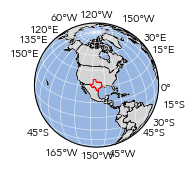

In [106]:
def _plot_globe(_ax, shape_):
    
    # --- Load data ---
    # World map (built in)
    world_ = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    world_ = world_.to_crs(epsg=4326)
    shape_ = shape_.to_crs(epsg=4326)
    
    # Draw world boundaries
    _ax.add_geometries(world_.geometry,
                       crs=ccrs.PlateCarree(),
                       facecolor="none",
                       edgecolor="k",
                       linewidth=0.25)
    
    # Draw Texas boundaries
    _ax.add_geometries(shape_.geometry,
                       crs=ccrs.PlateCarree(),
                       facecolor="none",
                       edgecolor="r", 
                       zorder=10,
                       linewidth=.75)
    
    # --- Graticule: lat/lon lines ---
    gl = _ax.gridlines(crs=ccrs.PlateCarree(),
                       draw_labels=True,
                       linewidth=0.4,
                       color="white",
                       alpha=.825,
                       xlocs=range(-180, 181, 15),
                       ylocs=range(-90, 91, 15))
    
    # Use proper degree formatting
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    # Turn off labels on some sides (small inset => reduce clutter)
    # gl.top_labels = False
    # gl.right_labels = False
    # You can also turn these off if too busy:
    gl.bottom_labels = False
    gl.left_labels = False
    
    # Label style
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    
    _ax.coastlines(linewidth=0.5)
    # Add water/land colors using Cartopy features (no satellite)
    _ax.add_feature(cfeature.OCEAN, zorder=0)
    _ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=1)
    #_ax.stock_img()  # shaded relief-style world image
    _ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=2)
    _ax.set_global()

    return _ax

shape_centroid = TX_.geometry.unary_union.centroid

# --- Left: world in orthographic (circular) projection centered on Texas ---
ortho = ccrs.Orthographic(central_longitude=shape_centroid.x, 
                          central_latitude=shape_centroid.y)
    
fig, _ax = plt.subplots(1, 1, 
                        subplot_kw={"projection": ortho},
                        figsize=(2, 2))

_plot_globe(_ax, TX_)

# plt.savefig(path_to_images + r"/texas_globe.pdf", 
#             bbox_inches="tight")


plt.tight_layout()

plt.show()

(364, 288, 211) (364, 288, 211)
(288, 211) (288, 187)


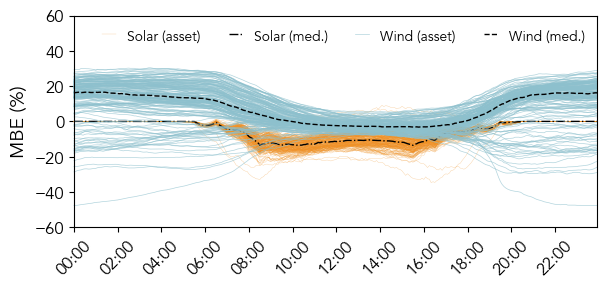

In [25]:
print(F_ts_solar_.shape, E_ts_solar_.shape)

e_ts_solar_ = np.mean(F_ts_solar_ - E_ts_solar_, axis = 0)
e_ts_wind_  = np.mean(F_ts_wind_ - E_ts_wind_, axis = 0)
print(e_ts_solar_.shape, e_ts_wind_.shape)

fig, _ax = plt.subplots(figsize = (6.75, 2.75))  # Adjust figure size as needed

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*e_ts_solar_[:, 0], 
         color = '#ef9226', 
         lw    = .25, 
         alpha = 0.5,
         label = 'Solar (asset)', 
         clip_on = False)

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*e_ts_solar_[:, 1:], 
         color = '#ef9226', 
         lw    = .25, 
         alpha = 0.5,
         clip_on = False)

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*np.median(e_ts_solar_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '-.',
         lw    = 1., 
         label = 'Solar (med.)', 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*e_ts_wind_[:, 0], 
         color = '#8dc0cd', 
         alpha = 0.675,
         lw    = .5, 
         label = 'Wind (asset)', 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*e_ts_wind_[:, 1:], 
         color = '#8dc0cd', 
         alpha = 0.675,
         lw    = .5, 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*np.median(e_ts_wind_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '--',
         lw    = 1., 
         label = 'Wind (med.)', 
         clip_on = False)

_ax.tick_params(axis="both", labelsize=12)
_ax.set_xticks(dt_[::24], dx_[::24], rotation=45)
_ax.set_ylabel('MBE (%)', size=14)
_ax.set_ylim(-60, 60)
_ax.set_xlim(0, e_ts_wind_.shape[0]*5 - 5)

_ax.legend(frameon=False, 
           ncol=4, 
           #loc="upper left", 
           fontsize=10)

plt.show()

In [29]:
print(F_ts_solar_.shape, E_ts_solar_.shape)
print(F_tr_solar_.shape, E_tr_solar_.shape)

print(F_ts_wind_.shape, E_ts_wind_.shape)
print(F_tr_wind_.shape, E_tr_wind_.shape)

(364, 288, 211) (364, 288, 211)
(363, 288, 211) (363, 288, 211)
(364, 288, 187) (364, 288, 187)
(363, 288, 187) (363, 288, 187)


(288, 211) (288, 40)


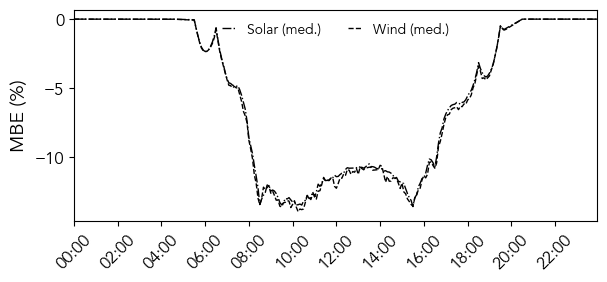

In [56]:
b_ts_solar_ = np.mean(F_ts_solar_ - E_ts_solar_, axis = 0)
b_ts_wind_  = np.mean(F_ts_solar_ - E_ts_solar_, axis = 0)[:, :40]
print(b_ts_solar_.shape, b_ts_wind_.shape)

fig, _ax = plt.subplots(figsize = (6.75, 2.75))  # Adjust figure size as needed

# _ax.plot(range(int(b_ts_solar_.shape[0]*5))[::5], 100.*b_ts_solar_[:, 0], 
#          color = '#ef9226', 
#          lw    = .5, 
#          alpha = 0.675,
#          label = 'Solar (asset)', 
#          clip_on = False)

# _ax.plot(range(int(b_ts_solar_.shape[0]*5))[::5], 100.*b_ts_solar_[:, 1:], 
#          color = '#ef9226', 
#          lw    = .5, 
#          alpha = 0.675,
#          clip_on = False)

_ax.plot(range(int(b_ts_solar_.shape[0]*5))[::5], 100.*np.median(b_ts_solar_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '-.',
         lw    = 1., 
         label = 'Solar (med.)', 
         clip_on = False)

# _ax.plot(range(int(b_ts_wind_.shape[0]*5))[::5], 100.*b_ts_wind_[:, 0], 
#          color = '#8dc0cd', 
#          alpha = 0.675,
#          lw    = .5, 
#          label = 'Wind (asset)', 
#          clip_on = False)

# _ax.plot(range(int(b_ts_wind_.shape[0]*5))[::5], 100.*b_ts_wind_[:, 1:], 
#          color = '#8dc0cd', 
#          alpha = 0.675,
#          lw    = .5, 
#          clip_on = False)

_ax.plot(range(int(b_ts_wind_.shape[0]*5))[::5], 100.*np.median(b_ts_wind_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '--',
         lw    = 1., 
         label = 'Wind (med.)', 
         clip_on = False)

_ax.tick_params(axis="both", labelsize=12)
_ax.set_xticks(dt_[::24], dx_[::24], rotation=45)
_ax.set_ylabel('MBE (%)', size=14)
#_ax.set_ylim(-50, 50)
_ax.set_xlim(0, b_ts_wind_.shape[0]*5 - 5)

_ax.legend(frameon=False, 
           ncol=4, 
           loc="upper center", 
           fontsize=10)

plt.show()

(288, 187) (288, 40)


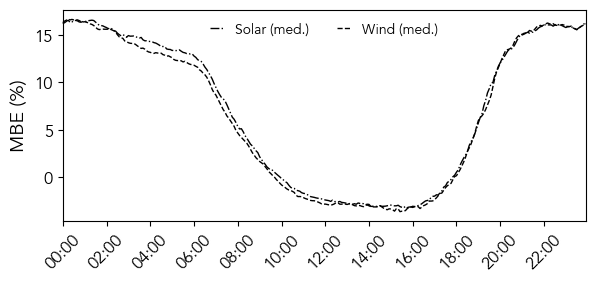

In [59]:
b_solar_ = np.mean(F_ts_wind_ - E_ts_wind_, axis = 0)
b_wind_  = np.mean(F_ts_wind_ - E_ts_wind_, axis = 0)[:, :40]
print(b_solar_.shape, b_wind_.shape)

fig, _ax = plt.subplots(figsize = (6.75, 2.75))  # Adjust figure size as needed

# _ax.plot(range(int(b_solar_.shape[0]*5))[::5], 100.*b_solar_[:, 0], 
#          color = '#ef9226', 
#          lw    = .5, 
#          alpha = 0.675,
#          label = 'Solar (asset)', 
#          clip_on = False)

# _ax.plot(range(int(b_solar_.shape[0]*5))[::5], 100.*b_solar_[:, 1:], 
#          color = '#ef9226', 
#          lw    = .5, 
#          alpha = 0.675,
#          clip_on = False)

_ax.plot(range(int(b_solar_.shape[0]*5))[::5], 100.*np.median(b_solar_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '-.',
         lw    = 1., 
         label = 'Solar (med.)', 
         clip_on = False)

# _ax.plot(range(int(b_wind_.shape[0]*5))[::5], 100.*b_wind_[:, 0], 
#          color = '#8dc0cd', 
#          alpha = 0.675,
#          lw    = .5, 
#          label = 'Wind (asset)', 
#          clip_on = False)

# _ax.plot(range(int(b_wind_.shape[0]*5))[::5], 100.*b_wind_[:, 1:], 
#          color = '#8dc0cd', 
#          alpha = 0.675,
#          lw    = .5, 
#          clip_on = False)

_ax.plot(range(int(b_wind_.shape[0]*5))[::5], 100.*np.median(b_wind_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '--',
         lw    = 1., 
         label = 'Wind (med.)', 
         clip_on = False)

_ax.tick_params(axis="both", labelsize=12)
_ax.set_xticks(dt_[::24], dx_[::24], rotation=45)
_ax.set_ylabel('MBE (%)', size=14)
#_ax.set_ylim(-50, 50)
_ax.set_xlim(0, b_wind_.shape[0]*5 - 5)

_ax.legend(frameon=False, 
           ncol=4, 
           loc="upper center", 
           fontsize=10)

plt.show()

(364, 288, 211) (364, 288, 211)
(288, 211) (288, 187)


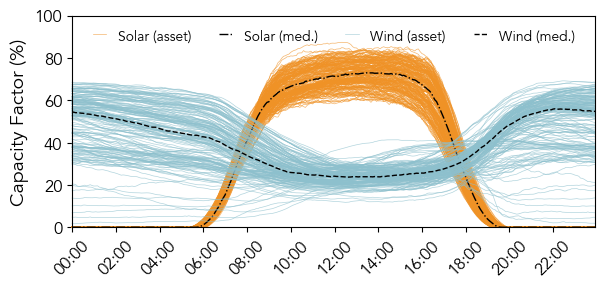

In [84]:
print(F_ts_solar_.shape, E_ts_solar_.shape)

e_ts_solar_ = np.mean(F_ts_solar_, axis = 0)
e_ts_wind_  = np.mean(F_ts_wind_, axis = 0)
print(e_ts_solar_.shape, e_ts_wind_.shape)

fig, _ax = plt.subplots(figsize = (6.75, 2.75))  # Adjust figure size as needed

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*e_ts_solar_[:, 0], 
         color = '#ef9226', 
         lw    = .5, 
         alpha = 0.675,
         label = 'Solar (asset)', 
         clip_on = False)

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*e_ts_solar_[:, 1:], 
         color = '#ef9226', 
         lw    = .5, 
         alpha = 0.675,
         clip_on = False)

_ax.plot(range(int(e_ts_solar_.shape[0]*5))[::5], 100.*np.median(e_ts_solar_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '-.',
         lw    = 1., 
         label = 'Solar (med.)', 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*e_ts_wind_[:, 0], 
         color = '#8dc0cd', 
         alpha = 0.675,
         lw    = .5, 
         label = 'Wind (asset)', 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*e_ts_wind_[:, 1:], 
         color = '#8dc0cd', 
         alpha = 0.675,
         lw    = .5, 
         clip_on = False)

_ax.plot(range(int(e_ts_wind_.shape[0]*5))[::5], 100.*np.median(e_ts_wind_, axis = 1), 
         color = 'k', 
         alpha = 1.,
         ls = '--',
         lw    = 1., 
         label = 'Wind (med.)', 
         clip_on = False)

_ax.tick_params(axis="both", labelsize=12)
_ax.set_xticks(dt_[::24], dx_[::24], rotation=45)
_ax.set_ylabel('Capacity Factor (%)', size=14)
_ax.set_ylim(0, 100)
_ax.set_xlim(0, e_ts_wind_.shape[0]*5 - 5)

_ax.legend(frameon=False, 
           ncol=4, 
           loc="upper center", 
           fontsize=10)

plt.savefig(path_to_images + r"/average_cf.pdf", 
            bbox_inches="tight")

plt.show()